In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

o:\Hackthons\KrishiOS\ai


In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

from configs.config import *

from training.dataset import create_dataset_and_loaders
from training.model import build_model
print("✅ Libraries Loaded")

✅ Libraries Loaded


In [5]:
_, val_dataset, _, val_loader = create_dataset_and_loaders(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

class_names = val_dataset.classes

print(f"Validation Images : {len(val_dataset)}")
print(f"Classes : {len(class_names)}")

Validation Images : 10861
Classes : 38


In [6]:
model = build_model(NUM_CLASSES)

checkpoint = torch.load(
    PROJECT_ROOT / "models" / "best_model.pth",
    map_location=DEVICE,
)

model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(DEVICE)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [7]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print(f"Validation Accuracy : {accuracy*100:.2f}%")

Validation Accuracy : 97.02%


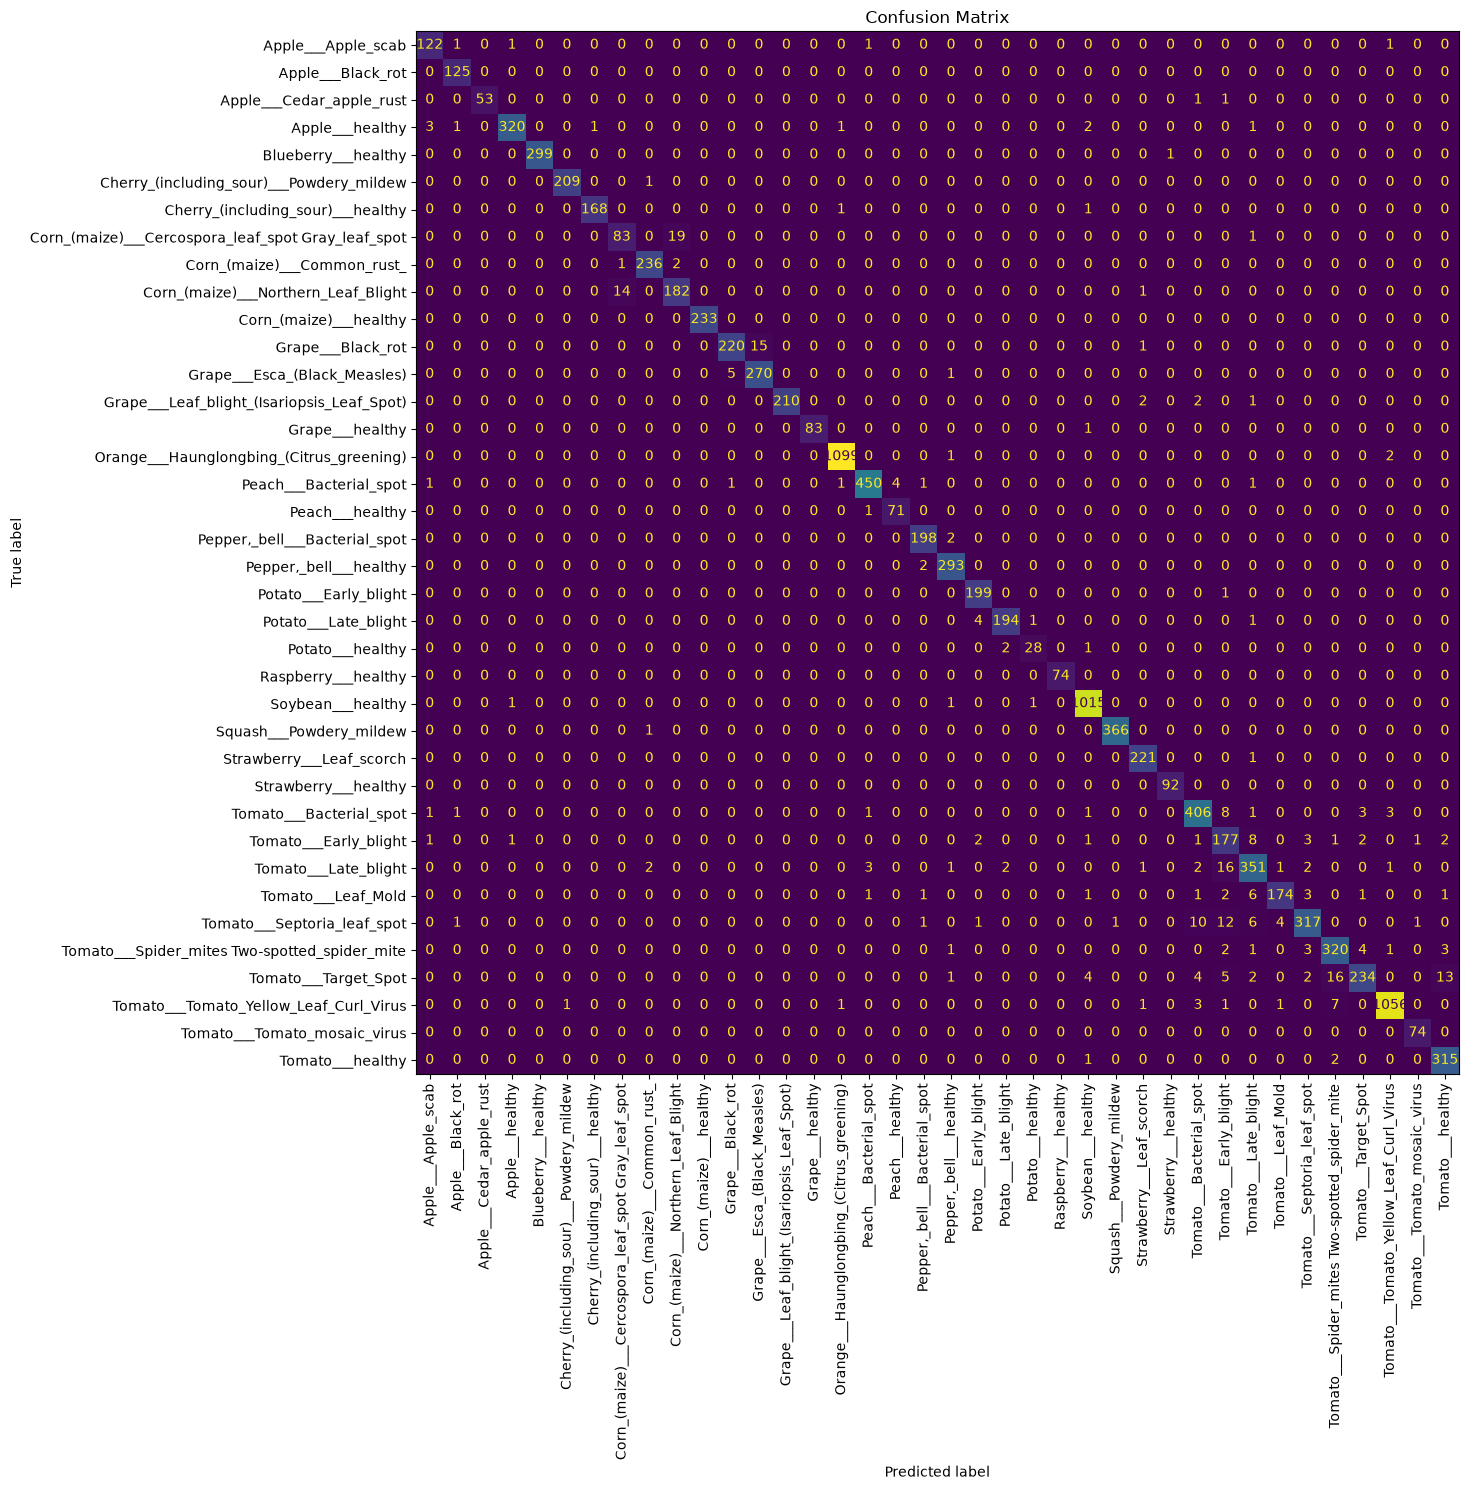

In [9]:
cm = confusion_matrix(
    y_true,
    y_pred,
)

fig, ax = plt.subplots(figsize=(15,15))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

disp.plot(
    xticks_rotation=90,
    ax=ax,
    colorbar=False,
)

plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "outputs" / "confusion_matrix.png",
    dpi=300,
)

plt.show()

In [10]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv(
    PROJECT_ROOT / "outputs" / "classification_report.csv"
)

,precision,recall,f1-score,support
Apple___Apple_scab,0.953125,0.968254,0.960630,126.000000
Apple___Black_rot,0.968992,1.000000,0.984252,125.000000
Apple___Cedar_apple_rust,1.000000,0.963636,0.981481,55.000000
Apple___healthy,0.990712,0.972644,0.981595,329.000000
Blueberry___healthy,1.000000,0.996667,0.998331,300.000000
Cherry_(including_sour)___Powdery_mildew,0.995238,0.995238,0.995238,210.000000
Cherry_(including_sour)___healthy,0.994083,0.988235,0.991150,170.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.846939,0.805825,0.825871,103.000000
Corn_(maize)___Common_rust_,0.983333,0.987448,0.985386,239.000000
Corn_(maize)___Northern_Leaf_Blight,0.896552,0.923858,0.910000,197.000000


In [11]:
class_accuracy = {}

for idx, class_name in enumerate(class_names):

    total = cm[idx].sum()

    correct = cm[idx][idx]

    class_accuracy[class_name] = (
        correct / total * 100
    )

accuracy_df = pd.DataFrame(
    class_accuracy.items(),
    columns=[
        "Class",
        "Accuracy",
    ],
)

display(accuracy_df)

accuracy_df.to_csv(
    PROJECT_ROOT / "outputs" / "class_accuracy.csv",
    index=False,
)

,Class,Accuracy
0,Apple___Apple_scab,96.825397
1,Apple___Black_rot,100.000000
2,Apple___Cedar_apple_rust,96.363636
3,Apple___healthy,97.264438
4,Blueberry___healthy,99.666667
5,Cherry_(including_sour)___Powdery_mildew,99.523810
6,Cherry_(including_sour)___healthy,98.823529
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,80.582524
8,Corn_(maize)___Common_rust_,98.744770
9,Corn_(maize)___Northern_Leaf_Blight,92.385787


In [12]:
import json

summary = {
    "accuracy": float(accuracy),
}

with open(
    PROJECT_ROOT / "outputs" / "evaluation_metrics.json",
    "w",
) as f:
    json.dump(summary, f, indent=4)

print("Evaluation results saved.")

Evaluation results saved.


In [13]:
print("=" * 60)
print("Evaluation Complete")
print(f"Accuracy : {accuracy*100:.2f}%")
print("Artifacts generated:")
print("- confusion_matrix.png")
print("- classification_report.csv")
print("- class_accuracy.csv")
print("- evaluation_metrics.json")

Evaluation Complete
Accuracy : 97.02%
Artifacts generated:
- confusion_matrix.png
- classification_report.csv
- class_accuracy.csv
- evaluation_metrics.json
